# PANDAS

Two core objects in Pandas: the DataFrame and the Series

DataFrame is a table. I contains an array of individual entries, each of which has a certain value. Each entry corresponds to a row and a column

In [1]:
import pandas as pd 

pd.DataFrame({'Apple': [30], 'Banana': [21]})

,Apple,Banana
0,30,21


In [2]:
pd.DataFrame({'Bob': ['I liked it.', 'It was awful.'], 'Sue': ['Pretty good.', 'Bland.']})

,Bob,Sue
0,I liked it.,Pretty good.
1,It was awful.,Bland.


In [ ]:
#adding row labels
pd.DataFrame({'Bob': ['I liked it.', 'It was awful.'],
              'Sue': ['Pretty good.', 'Bland.']},
              index=['Product A', 'Product B'])

,Bob,Sue
Product A,I liked it.,Pretty good.
Product B,It was awful.,Bland.


a SERIES is a sequence of data values, a list. It is a single column of a DataFrame. Has one overall name.

In [4]:
pd.Series([1, 2, 3], index=['2015 Sales', '2016 Sales', '2017 Sales'], name= 'Product A')

2015 Sales    1
2016 Sales    2
2017 Sales    3
Name: Product A, dtype: int64

# READING DATA FILES

The most basic form of storing data is a CSV file ("Comma-Separated Values"). It looks like this:

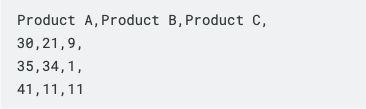


In [ ]:
wine_reviews = pd.read_csv("xxxxxxxx.csv")

In [ ]:
#check how large it is
wine_reviews.shape

In [ ]:
#exime the contents of the resultant DataFrame. head() grabs the first 5 rows.
wine_reviews.head

In [ ]:
#if the CSV file has a built-in index, make pandas use that column for the index, instead of creating a new one
wine_reviews = pd.read_csv("xxxxxxx.csv", index_col=0)

In [ ]:
#DataFrame to disk as a csv file with the name 'wine.csv'

wine_reviews.to_csv("wine.csv")

# INDEXING

In [2]:
import pandas as pd

data = {
    "city": ["Edinburgh", "Valencia", "Madrid", "London", "Paris", "Berlin", "Lisbon", "Rome"],
    "country": ["UK", "Spain", "Spain", "UK", "France", "Germany", "Portugal", "Italy"],
    "temperature_c": [12, 24, 20, 15, 18, 16, 22, 21],
    "population_millions": [0.5, 0.8, 6.7, 9.0, 2.1, 3.7, 0.5, 2.8],
    "is_coastal": [False, True, False, False, False, False, True, False]
}

df = pd.DataFrame(data)
df

,city,country,temperature_c,population_millions,is_coastal
0,Edinburgh,UK,12,0.5,False
1,Valencia,Spain,24,0.8,True
2,Madrid,Spain,20,6.7,False
3,London,UK,15,9.0,False
4,Paris,France,18,2.1,False
5,Berlin,Germany,16,3.7,False
6,Lisbon,Portugal,22,0.5,True
7,Rome,Italy,21,2.8,False


In [11]:
df.country

0          UK
1       Spain
2       Spain
3          UK
4      France
5     Germany
6    Portugal
7       Italy
Name: country, dtype: str

In [12]:
df['country']

0          UK
1       Spain
2       Spain
3          UK
4      France
5     Germany
6    Portugal
7       Italy
Name: country, dtype: str

In [13]:
df['country'][0]

'UK'

INDEXING

Contradictory to native python, indexing in Pandas are row-first, column-second
Two methods:
1. Index-based selection: iloc operator

In [ ]:
#get first row
df.iloc[0]

city                   Edinburgh
country                       UK
temperature_c                 12
population_millions          0.5
is_coastal                 False
Name: 0, dtype: object

In [15]:
#get first column
df.iloc[:, 0]

0    Edinburgh
1     Valencia
2       Madrid
3       London
4        Paris
5       Berlin
6       Lisbon
7         Rome
Name: city, dtype: str

In [16]:
#first column, first three rows
df.iloc[:3, 0]

0    Edinburgh
1     Valencia
2       Madrid
Name: city, dtype: str

In [17]:
#possible to pass a list
df.iloc[[1, 2, 4, 6], 1]

1       Spain
2       Spain
4      France
6    Portugal
Name: country, dtype: str

In [19]:
#last row
df.iloc[-1:]

,city,country,temperature_c,population_millions,is_coastal
7,Rome,Italy,21,2.8,False


2. Label-based selection: loc operator

In [22]:
df.loc[:, ['country', 'is_coastal']]

,country,is_coastal
0,UK,False
1,Spain,True
2,Spain,False
3,UK,False
4,France,False
5,Germany,False
6,Portugal,True
7,Italy,False


In [4]:
#city with highest temperature-to-population ratio
ratio_idx = (df.temperature_c / df.population_millions).idxmax()
df.loc[ratio_idx, 'city']

'Lisbon'

DIFFERENCES BTW LOC AND ILOC

iloc uses the Python stdlib indexing squeme (first element of range included and last excluded). ex: 0:10 will select entries 0,...,9

loc uses indexes inclusively. ex: 0:10 will select entries 0,...,10



# CONDITIONAL SELECTION

- & is and
- | is or

In [23]:
df.country == 'UK'

0     True
1    False
2    False
3     True
4    False
5    False
6    False
7    False
Name: country, dtype: bool

In [24]:
df.loc[df.country == 'UK']

,city,country,temperature_c,population_millions,is_coastal
0,Edinburgh,UK,12,0.5,False
3,London,UK,15,9.0,False


In [29]:
df.loc[(df.country == 'UK') & ((df.population_millions >= 4) | (df.temperature_c >= 15))]

,city,country,temperature_c,population_millions,is_coastal
3,London,UK,15,9.0,False


In [30]:
df.loc[df.country.isin(['Spain', 'Portugal'])]

,city,country,temperature_c,population_millions,is_coastal
1,Valencia,Spain,24,0.8,True
2,Madrid,Spain,20,6.7,False
6,Lisbon,Portugal,22,0.5,True


In [31]:
#highlight values wich are (or are not) empty
df.loc[df.temperature_c.notnull()]

,city,country,temperature_c,population_millions,is_coastal
0,Edinburgh,UK,12,0.5,False
1,Valencia,Spain,24,0.8,True
2,Madrid,Spain,20,6.7,False
3,London,UK,15,9.0,False
4,Paris,France,18,2.1,False
5,Berlin,Germany,16,3.7,False
6,Lisbon,Portugal,22,0.5,True
7,Rome,Italy,21,2.8,False


# ASSIGNING DATA

In [33]:
#iterative values backwards
df['country'] = range(len(df), 0, -1)
df['country']

0    8
1    7
2    6
3    5
4    4
5    3
6    2
7    1
Name: country, dtype: int64

In [34]:
df['country'] = 'Spain'
df['country']

0    Spain
1    Spain
2    Spain
3    Spain
4    Spain
5    Spain
6    Spain
7    Spain
Name: country, dtype: str

# MANIPULATING THE INDEX

In [ ]:
#make the column 'city' be the index
df.set_index("city")

,country,temperature_c,population_millions,is_coastal
city,,,,
Edinburgh,Spain,12,0.5,False
Valencia,Spain,24,0.8,True
Madrid,Spain,20,6.7,False
London,Spain,15,9.0,False
Paris,Spain,18,2.1,False
Berlin,Spain,16,3.7,False
Lisbon,Spain,22,0.5,True
Rome,Spain,21,2.8,False
